# Chandra/HETG observation of Vela X-1 (2001) — detector-space analysis

BLiSS applied to the Chandra HETG spectrum of Vela X-1 (ObsID 1927) loaded directly
from the OGIP files. In this example MEG am will be analized.

The ±1 orders of each arm were combined with CIAO:

    combine_spectra src_spectra="meg_-1.pha.gz,heg_1.pha.gz" outroot=meg \
        src_arfs="meg_-1.arf.gz,meg_1.arf.gz" src_rmfs="meg_-1.rmf.gz,meg_1.rmf.gz" \
        method=sum clobber=yes

This observation corresponds to orbital phase 0.5 in
[Goldstein, Huenemoerder & Blank (2004)](https://arxiv.org/abs/astro-ph/0403495).
Use the **ObsID 1927 / phase 0.5** columns of their Tables 2 and 3 for a line comparison.

In [1]:
# Import the public BLiSS API and the utilities used throughout this notebook.
from bliss import *
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from time import perf_counter

from bliss.line_search.blind_line_search import (
    BlindLineSearchConfig,)

## 1. Input files and visualize spectra

In [18]:
chandra_path = Path("chandra_spectrum")

pha, rmf, arf = [
    chandra_path / f"meg.{ext}"
    for ext in ("pha", "rmf", "arf")
]

spectrum = prepare_spectrum(
    pha_path=pha,
    rmf_path=rmf,
    arf_path=arf,
)


### 1.2. Visualize native spectra (no rebining)

Text(0, 0.5, 'counts s$^{-1}$ keV$^{-1}$')

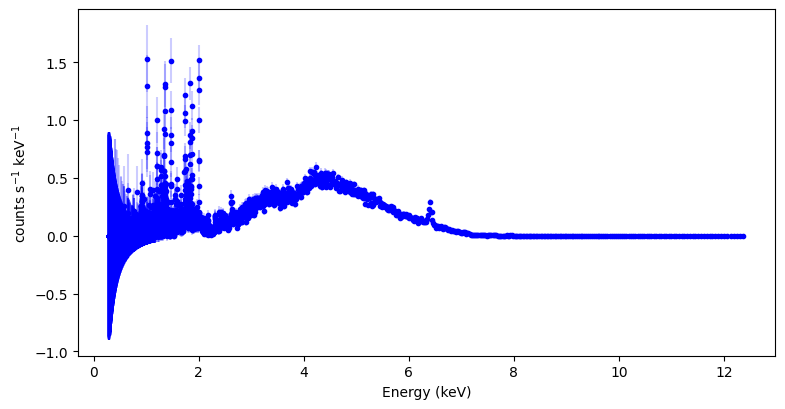

In [16]:

plt.figure(figsize=(9, 4.5))
plt.errorbar(spectrum.energy, spectrum.values, yerr=spectrum.uncertainties,fmt="b.",alpha=0.2)
plt.errorbar(spectrum.energy, spectrum.values,fmt="b.")
plt.xlabel("Energy (keV)")
plt.ylabel("counts s$^{-1}$ keV$^{-1}$")


### 2. Visual inspeccion of the spectra. 

4096 bins, median width 0.27 eV, exposure 58862 s


Text(0, 0.5, 'counts s$^{-1}$ keV$^{-1}$')

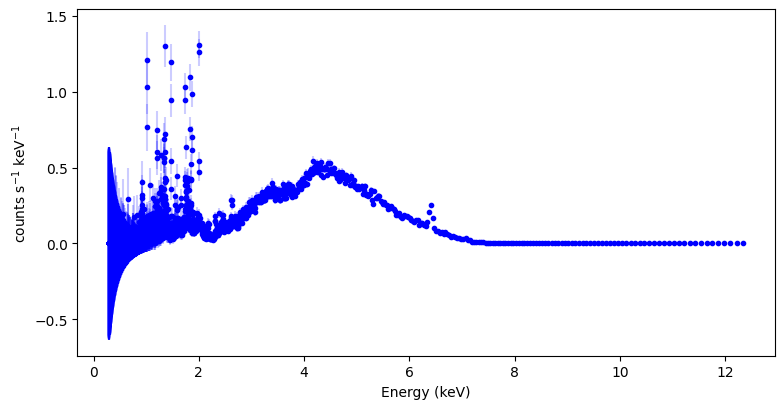

In [17]:
# Combine three input bins per group after background subtraction.
spectrum_bins = prepare_spectrum(
    pha_path=pha,
    rmf_path=rmf,
    rebin_method="bins",
    rebin_scale=2,
)

print(
    f"{len(spectrum_bins.energy)} bins, "
    f"median width {1e3 * np.median(spectrum_bins.bin_width):.2f} eV, "
    f"exposure {spectrum_bins.native.exposure:.0f} s"
)

plt.figure(figsize=(9, 4.5))
plt.errorbar(spectrum_bins.energy, spectrum_bins.values, yerr=spectrum_bins.uncertainties,fmt="b.",alpha=0.2)
plt.errorbar(spectrum_bins.energy, spectrum_bins.values,fmt="b.")
plt.xlabel("Energy (keV)")
plt.ylabel("counts s$^{-1}$ keV$^{-1}$")

## 2. Define and inspect the baseline

The baseline is a runing median of basline_window 0.4 keV as a default. It explodes the diference in variations caused by the contimun (slow) compared to fast emission lines (sharp spikes)

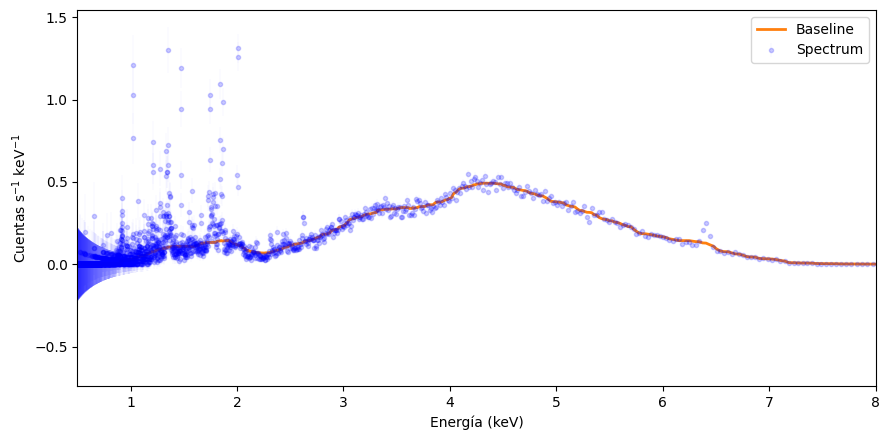

In [29]:
baseline_window = 0.4 #Default

baseline_bins, info_bins = base_calculator(
    spectrum_bins.energy,
    spectrum_bins.values,
    baseline_window=baseline_window,
    return_info=True)


# Figure ##########################################
fig, ax = plt.subplots(figsize=(9, 4.5))

# Spectrum
ax.errorbar(
    spectrum_bins.energy,
    spectrum_bins.values,
    yerr = spectrum_bins.uncertainties,
    fmt=".",
    color="blue",
    linewidth=0.1,
    alpha=0.2,
    label="Spectrum"
)

# Baseline
ax.plot(
    spectrum_bins.energy,
    baseline_bins,
    color="tab:orange",
    linewidth=2,
    label="Baseline",
)

ax.set(
    xlim=(0.5, 8),
    xlabel="Energía (keV)",
    ylabel=r"Cuentas s$^{-1}$ keV$^{-1}$",
)

ax.legend()
fig.tight_layout()
plt.show()

## 5. Run a quick candidate search without simulations

Setting `num_synthetic_simulations=0` detects and locally fits candidates without assigning simulation-based significance. This is useful for an initial inspection; the resulting candidates are not confirmed detections.

In [31]:
en1, en2 = 0.5, 8

inicio = perf_counter()

candidate_lines_not_evaluated = find_candidate_lines(
    pha=pha,
    rmf=rmf,
    rebin_method="bins",
    rebin_scale=2,
    en1=en1,
    en2=en2,
    num_synthetic_simulations=0,
    synthetic_seed=1,
)

tiempo = perf_counter() - inicio

print(f"Tiempo total: {tiempo:.2f} s ({tiempo / 60:.2f} min)")

Tiempo total: 8.34 s (0.14 min)


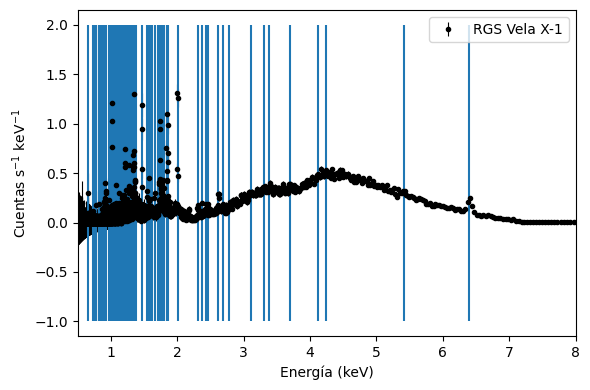

In [33]:
# Mark quick-search centers on a separately prepared three-bin spectrum.
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.errorbar(
    spectrum_bins.energy,
    spectrum_bins.values,
    yerr = spectrum_bins.uncertainties,
    fmt=".",
    color="black",
    linewidth=0.8,
    label="RGS Vela X-1", 
)

ax.set(
    xlim=(0.5, 8),
    xlabel="Energía (keV)",
    ylabel=r"Cuentas s$^{-1}$ keV$^{-1}$",
)

for i in range(len(candidate_lines_not_evaluated )):
    plt.vlines(x=candidate_lines_not_evaluated .center[i], ymin=-1, ymax=2)




ax.legend()
fig.tight_layout()
plt.show()

### 6. Run the complete pipeline: null spectra, global p-values, and BLiSS scores

In this example, we run the complete BLiSS pipeline. Compared with Section 5, we modify several default configuration options and generate synthetic null spectra to estimate global Monte Carlo p-values and compute BLiSS scores.

Error fitting block 1: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Tiempo total: 758.85 s (12.65 min)


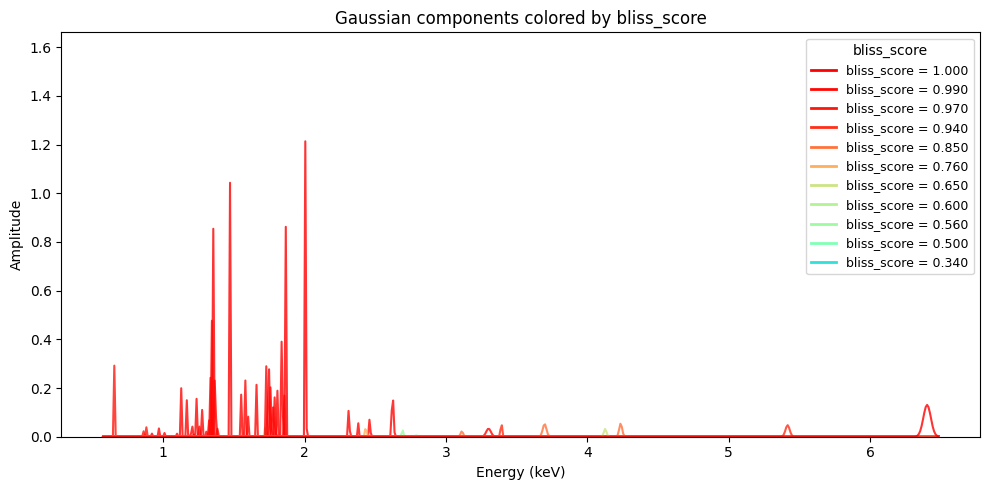

,center,ecenter,sigma,esigma,amplitude,eamplitude,area,earea,ew,relative_power,snr_peak,snr_area,bliss_score,response_feature,p_global_area,p_global_snr_area,p_global_snr_peak,p_global_ew,p_global_relative_power
0,0.653757,0.000183,0.000239,0.000147,0.292059,0.203392,0.000175,0.000112,NaN,1.000000,1.875026,1.558315,0.97,False,1.000000,1.000000,1.000000,NaN,1.0
1,0.740797,0.000447,0.000376,0.000423,0.116626,0.130670,0.000110,0.000112,NaN,1.000000,0.999920,0.979458,0.97,False,1.000000,1.000000,1.000000,NaN,1.0
2,0.744554,0.000574,0.000388,0.000548,0.090121,0.121783,0.000088,0.000111,NaN,1.000000,0.801578,0.788885,0.97,False,1.000000,1.000000,1.000000,NaN,1.0
3,0.775078,0.000294,0.000331,0.000247,0.172271,0.141826,0.000143,0.000107,NaN,1.000000,1.585683,1.336536,0.97,False,1.000000,1.000000,1.000000,NaN,1.0
4,0.817207,0.001321,0.000212,0.001521,0.268964,2.760492,0.000143,0.000449,NaN,1.000000,2.758406,0.318069,0.97,False,1.000000,1.000000,0.990099,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,3.697387,0.006423,0.012994,0.006384,0.052502,0.022613,0.001710,0.000731,4.972855,0.057181,2.012374,2.340621,0.85,False,0.346535,0.950495,1.000000,0.920792,1.0
76,4.125760,0.010700,0.009282,0.007949,0.032215,0.026444,0.000749,0.000671,1.622438,0.031955,1.246488,1.117122,0.65,False,0.990099,1.000000,1.000000,1.000000,1.0
77,4.235478,0.006488,0.010359,0.006217,0.054464,0.028794,0.001414,0.000742,2.931388,0.049050,2.105170,1.906212,0.85,False,0.534653,1.000000,1.000000,1.000000,1.0
78,5.416065,0.006341,0.014757,0.011036,0.047506,0.028191,0.001757,0.000729,6.337327,0.063327,3.051473,2.409594,0.94,False,0.306931,0.900990,0.910891,0.643564,1.0


In [43]:
N_SIM = 100
SEED = 1
output_dir = "bliss_velax1_chandra"

config = BlindLineSearchConfig(
    en1=0.5,
    en2=8.0,
    energy_pad=0.0,
    rebin_method="bins",
    rebin_scale=2,  # combina 2 canales consecutivos
    baseline_window=0.4,
    max_sigma_line=0.1,
    num_synthetic_simulations=N_SIM,
    synthetic_seed=SEED,
    noise_model="poisson",
)

inicio = perf_counter()

pipeline = BlindLineSearchPipeline(config=config)
candidates_evaluated = pipeline.run(
    pha=pha,
    rmf=rmf,
    arf=arf,
    output_dir=output_dir,
)

tiempo = perf_counter() - inicio

print(f"Tiempo total: {tiempo:.2f} s ({tiempo / 60:.2f} min)")

plot_bliss_score(candidates_evaluated)
candidates_evaluated

### 7. Filter the candidate lines

Candidates can be filtered using `p_global_area`, `p_global_snr_area`,
`p_global_snr_peak`, `p_global_ew`, and `p_global_relative_power`.
The BLiSS score, derived using a Gaussian mixture model, measures how
different a candidate's properties are from those of candidates recovered
from the null distribution. It should not be interpreted as a probability.

With `N_SIM = 100`, the minimum attainable Monte Carlo p-value is

\[
p_{\mathrm{min}} = \frac{1}{N_{\mathrm{sim}} + 1}
                  = \frac{1}{101}
                  \simeq 0.0099.
\]

In this example we will use BLiSS score > 0.9 and anyof the p_values < 0.05

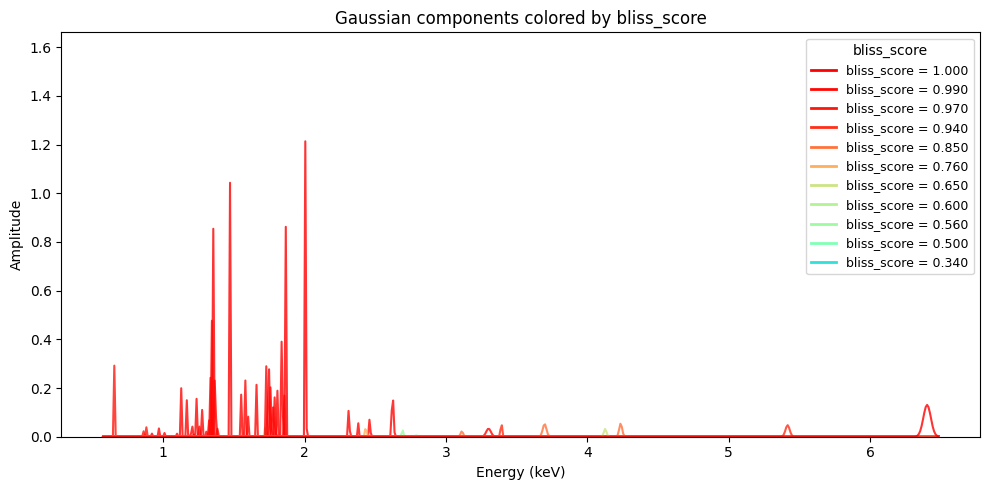

In [46]:
plot_bliss_score(candidates_evaluated)

In [62]:
pvalue_columns = [
    "p_global_area",
    "p_global_snr_area",
    "p_global_snr_peak",
    "p_global_ew",
    "p_global_relative_power",
]

selected_candidates = candidates_evaluated.loc[
    candidates_evaluated[pvalue_columns].lt(0.01).any(axis=1)
    | candidates_evaluated["bliss_score"].gt(0.95)
].copy()

selected_candidates.head()

,center,ecenter,sigma,esigma,amplitude,eamplitude,area,earea,ew,relative_power,snr_peak,snr_area,bliss_score,response_feature,p_global_area,p_global_snr_area,p_global_snr_peak,p_global_ew,p_global_relative_power
0,0.653757,0.000183,0.000239,0.000147,0.292059,0.203392,0.000175,0.000112,NaN,1.0,1.875026,1.558315,0.97,False,1.0,1.0,1.000000,NaN,1.0
1,0.740797,0.000447,0.000376,0.000423,0.116626,0.130670,0.000110,0.000112,NaN,1.0,0.999920,0.979458,0.97,False,1.0,1.0,1.000000,NaN,1.0
2,0.744554,0.000574,0.000388,0.000548,0.090121,0.121783,0.000088,0.000111,NaN,1.0,0.801578,0.788885,0.97,False,1.0,1.0,1.000000,NaN,1.0
3,0.775078,0.000294,0.000331,0.000247,0.172271,0.141826,0.000143,0.000107,NaN,1.0,1.585683,1.336536,0.97,False,1.0,1.0,1.000000,NaN,1.0
4,0.817207,0.001321,0.000212,0.001521,0.268964,2.760492,0.000143,0.000449,NaN,1.0,2.758406,0.318069,0.97,False,1.0,1.0,0.990099,NaN,1.0


### 7. Global fit

We fit all lines at the same time. Please, take into account that this do no replace a fit with a phisical contimun and that this in an exploratory tool.

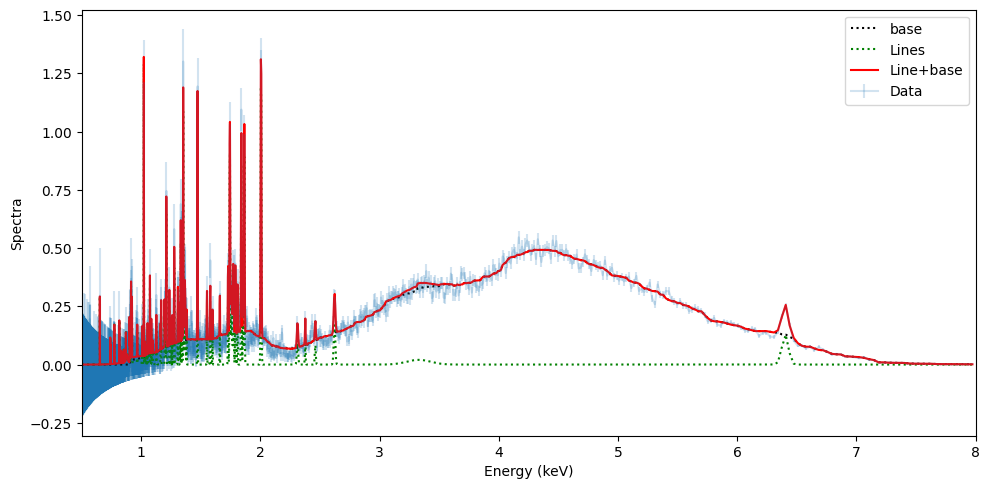

In [63]:
selected_candidates_global_fit = fit_global(
    selected_candidates,
    spectrum_bins,
    energy_min=en1, energy_max=en2,
    base=baseline_bins,
)

#### 8. Identify the emission lines within a Doppler window

In [64]:
v_dop=800
add_most_probable_ion(selected_candidates_global_fit, v_doppler_kms=v_dop )

,ion,doppler_kms,center,ecenter,sigma,esigma,amplitude,eamplitude,area,earea,...,relative_power,snr_peak,snr_area,bliss_score,response_feature,p_global_area,p_global_snr_area,p_global_snr_peak,p_global_ew,p_global_relative_power
0,o_viii,128.385339,0.653757,0.000183,0.000238,0.000147,0.291801,0.203409,0.000174,0.000112,...,1.000000,1.873370,1.555596,0.97,False,1.000000,1.000000,1.000000,NaN,1.0
1,o_vii,793.113164,0.740791,0.000442,0.000361,0.000413,0.116470,0.133120,0.000105,0.000111,...,1.000000,0.998583,0.950225,0.97,False,1.000000,1.000000,1.000000,NaN,1.0
2,fe_viii,467.017433,0.744558,0.000578,0.000376,0.000556,0.088395,0.123946,0.000083,0.000110,...,1.000000,0.786220,0.755992,0.97,False,1.000000,1.000000,1.000000,NaN,1.0
3,o_viii,180.232937,0.775076,0.000298,0.000315,0.000240,0.171684,0.143605,0.000136,0.000106,...,1.000000,1.580276,1.279762,0.97,False,1.000000,1.000000,1.000000,NaN,1.0
4,o_viii,100.946174,0.817250,0.238891,0.000149,0.369335,0.550686,4308.660999,0.000206,1.100681,...,1.000000,5.647657,0.000187,0.97,False,1.000000,1.000000,0.990099,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,si_xiv,67.602883,2.376622,0.001369,0.002287,0.000992,0.119774,0.046097,0.000687,0.000228,...,0.396162,4.680735,3.010649,0.99,False,1.000000,0.217822,0.168317,0.326733,1.0
62,s_xv,58.386433,2.461118,0.001526,0.004072,0.001480,0.086871,0.030360,0.000887,0.000286,...,0.287165,3.273164,3.094744,0.99,False,0.990099,0.198020,0.722772,0.297030,1.0
63,s_xvi,-43.102469,2.622295,0.001116,0.006373,0.001043,0.174639,0.028778,0.002790,0.000419,...,0.362474,6.243603,6.656888,0.99,False,0.049505,0.009901,0.029703,0.158416,1.0
64,ar_xviii,502.719070,3.328565,0.043095,0.100000,0.042847,0.020193,0.007704,0.005062,0.001886,...,0.028823,0.711171,2.683343,0.99,False,0.574257,1.000000,1.000000,0.960396,1.0


### EXTRA: Inspect only the low energy range

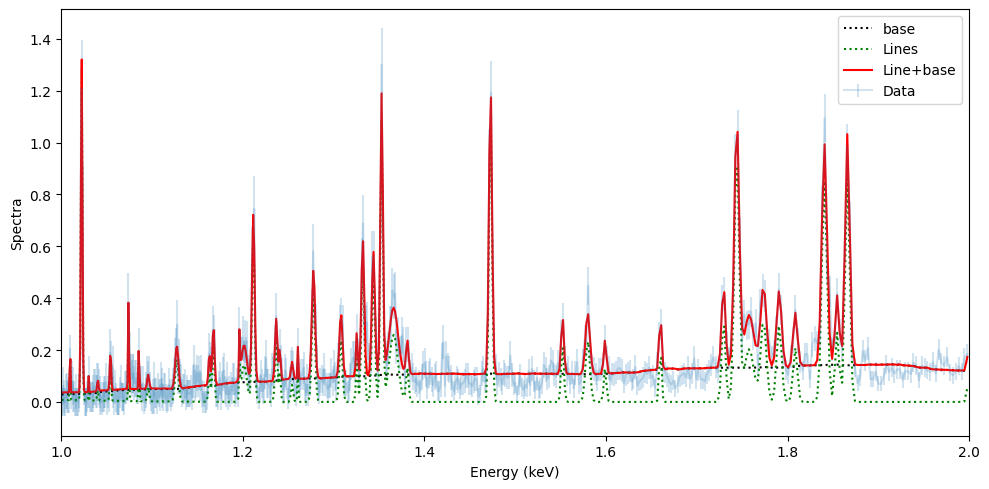

In [67]:
selected_candidates_global_fit_low = fit_global(
    selected_candidates,
    spectrum_bins,
    energy_min=1, energy_max=2,
    base=baseline_bins,
)

In [68]:
selected_candidates_global_fit_low.head()

,center,ecenter,sigma,esigma,amplitude,eamplitude,area,earea,ew,relative_power,snr_peak,snr_area,bliss_score,response_feature,p_global_area,p_global_snr_area,p_global_snr_peak,p_global_ew,p_global_relative_power
0,0.653757,0.000183,0.000238,0.000147,0.291801,0.203409,0.000174,0.000112,NaN,1.0,1.873370,1.555596,0.97,False,1.0,1.0,1.000000,NaN,1.0
1,0.740791,0.000442,0.000361,0.000413,0.116470,0.133120,0.000105,0.000111,NaN,1.0,0.998583,0.950225,0.97,False,1.0,1.0,1.000000,NaN,1.0
2,0.744558,0.000578,0.000376,0.000556,0.088395,0.123946,0.000083,0.000110,NaN,1.0,0.786220,0.755992,0.97,False,1.0,1.0,1.000000,NaN,1.0
3,0.775076,0.000298,0.000315,0.000240,0.171684,0.143605,0.000136,0.000106,NaN,1.0,1.580276,1.279762,0.97,False,1.0,1.0,1.000000,NaN,1.0
4,0.817250,0.238891,0.000149,0.369335,0.550686,4308.660999,0.000206,1.100681,NaN,1.0,5.647657,0.000187,0.97,False,1.0,1.0,0.990099,NaN,1.0
